# Public Sentiment and Discussion Patterns Surrounding Formula 1 Safety on X

**Course:** COSC2671 Social Media and Network Analytics  
**Assignment:** Assignment 2  
**Topic:** Formula 1 safety discussions on Youtube 

This notebook investigates how users on Youtube discuss Formula 1 safety issues. The analysis combines text preprocessing, exploratory data analysis, sentiment analysis, topic modelling, and network analysis to understand the main themes and patterns in public discussion.

## 1. Introduction (draft 1)

### Discussion
 This study analyses public discussion on Youtube around Formula 1 safety to identify dominant themes, sentiment patterns, and network structures within safety-related conversations.

Possible research questions:

1. What are the most common topics in F1 safety discussions on Youtube?
2. Is public sentiment mostly positive, negative, or neutral?
3. Which hashtags, keywords, or user mentions are most central in the discussion network?
4. How do sentiment and topic patterns connect with network communities?

Social media platforms have become a primary source of discussion, opinion formation, and exchange of information. Users not only express their views through text but also interact with one another, forming complex networks of influence and engagement. 
As a result, analysing online content requires more than just traditional text mining techniques — it demands an integrated approach that considers both what people say and how they are connected.

This study explores discussions surrounding *how does social media discussion influence perceptions of safety in Formula 1 after major accidents* by combining Natural Language Processing (NLP) and network analysis. 
The goal is to move beyond surface-level insights and uncover deeper patterns in sentiment, and interaction structures, by leveraging methods such as sentiment analysis, topic modelling, and transformer-based language models. The textual content of user-generated data can be systematically examined. At the same time, constructing and analysing interaction networks enables the identification of influential entities, community structures, and patterns of information flow.

## 2. Setup and Imports

Install the required libraries first if needed:

In [1]:
!pip install google-api-python-client pandas numpy matplotlib seaborn nltk textblob langdetect scikit-learn networkx python-louvain wordcloud transformers torch sentence-transformers deep_translator

In [2]:
# Core data tools
import os
import re
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# YouTube API
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

# Language detection
from langdetect import detect, LangDetectException

# NLP
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Feature extraction and topic modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Network analysis
import networkx as nx

# Optional community detection
try:
    import community as community_louvain
    HAS_LOUVAIN = True
except ImportError:
    HAS_LOUVAIN = False

# Optional BERT / sentence embeddings
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except ImportError:
    HAS_SENTENCE_TRANSFORMERS = False

# Download NLTK resources if needed
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. YouTube API

In [3]:
# ── YouTubeProcessing.py ───────────────────────────────────
# Provides the YouTubeProcessing class with a .process() method.
# Centralises tokenisation + stopword filtering (no stemming).
from YouTubeProcessing import YouTubeProcessing

# ── youtubeTextProcessing.py ───────────────────────────────
# Provides processText() which adds Porter stemming on top.
# This function is what youtubeTextProcessing.py uses in its main loop.


print('Helper modules imported.')
print('  YouTubeProcessing.process() — tokenise + filter (no stemming)')
print('  processText()               — tokenise + stem + stopword removal')

Helper modules imported.
  YouTubeProcessing.process() — tokenise + filter (no stemming)
  processText()               — tokenise + stem + stopword removal


## 5. Collect Video Metadata

This function searches YouTube for relevant videos and stores key metadata. Video-level metadata is useful for EDA and for linking comment trends back to popular videos.

In [4]:
from fetchYoutubeAPI import (
    SEARCH_QUERIES,
    search_videos_for_query,
    get_video_details
)

from youtubeClient import youtubeClient

client = youtubeClient()

MAX_TOTAL_VIDEOS = 60
VIDEOS_PER_QUERY = 10

all_items = []

for query in SEARCH_QUERIES:

    # Stop once enough videos collected
    if len(all_items) >= MAX_TOTAL_VIDEOS:
        break

    try:
        print(f"Searching: {query}")

        items = search_videos_for_query(
            client=client,
            query=query,
            max_videos=VIDEOS_PER_QUERY,
            published_after="2020-01-01T00:00:00Z"
        )

        all_items.extend(items)

        time.sleep(0.2)

    except HttpError as e:
        print(f"API error for query '{query}': {e}")

# Convert raw search results into video IDs
video_ids = [
    item["id"]["videoId"]
    for item in all_items
    if "id" in item and "videoId" in item["id"]
]

# Remove duplicates
video_ids = list(dict.fromkeys(video_ids))

# Final cap on total videos
video_ids = video_ids[:MAX_TOTAL_VIDEOS]

# Fetch detailed metadata/statistics
videos = get_video_details(client, video_ids)

video_df = pd.DataFrame(videos)

print(video_df.shape)
video_df.head()

Searching: Formula 1 crash analysis
Searching: F1 major accidents analysis
Searching: Formula 1 safety discussion
Searching: F1 halo safety analysis
Searching: Formula 1 dangerous crashes
Searching: Jules Bianchi crash analysis
(47, 10)


,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category,comments
0,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,4703BVI4Giw,FORMULA 1,2026-05-05T14:30:35Z,108186,2851,318,849,safety_discussion,[]
1,How Grosjean's Accident Happened | 2020 Bahrain Grand Prix | Jolyon Palmer Analysis,EyTeDaiUL6s,FORMULA 1,2020-12-01T19:30:01Z,2864532,56257,2311,692,safety_discussion,[]
2,The Horrifying Tragedy F1 Wants You To Forget..,6D4j1P0RcL4,DailyFuelUp,2025-04-11T12:00:15Z,766706,7228,565,696,safety_discussion,[]
3,Grosjean's Insane Fireball Crash | Formula 1: Drive To Survive S3 | Netflix,7YMjw2sjXqU,Still Watching Netflix,2021-03-23T12:00:00Z,47857173,714749,21315,409,safety_discussion,[]
4,3D Reconstruction of Gilles Villeneuve’s F1 Fatal Crash.,7O-PHymGHxI,3DCrash,2026-02-24T19:10:27Z,189758,2911,241,506,safety_discussion,[]


In [5]:
# Save raw video metadata
os.makedirs("data", exist_ok=True)
video_df.to_csv("data/f1_safety_videos.csv", index=False)
video_df.to_json("data/f1_safety_videos.json", orient="records", indent=2)
print("Saved video metadata.")

Saved video metadata.


## 6. Collect YouTube Comments

The function below collects top-level comments from each video. Replies can be added later, but top-level comments are usually enough for sentiment, topic modelling, and co-occurrence networks.

The notebook saves raw comments so the API does not need to be called repeatedly.

In [6]:
from fetchYoutubeAPI import get_comments_for_video
from youtubeClient import youtubeClient

client = youtubeClient()

MAX_COMMENTS_PER_VIDEO = 500

# Collect comments
all_comments = []

for idx, row in video_df.iterrows():

    print(
        f"Collecting comments for "
        f"{idx+1}/{len(video_df)}: "
        f"{row['title'][:80]}"
    )

    comments = get_comments_for_video(
        client=client,
        video_id=row["videoId"],
        max_comments=MAX_COMMENTS_PER_VIDEO
    )

    # Add video metadata into each comment
    for c in comments:
        c["videoId"] = row["videoId"]
        c["videoTitle"] = row["title"]

    all_comments.extend(comments)

comments_df = pd.DataFrame(all_comments)

print(comments_df.shape)
comments_df.head()

(14022, 8)


,author,text,originalText,originalLang,publishedAt,likeCount,videoId,videoTitle
0,@SundayDriveF1,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,en,2026-05-05T14:35:05Z,169,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis
1,@MarcelusTKW,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,en,2026-05-07T09:15:38Z,29,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis
2,@ConnorPenfold,The opening 10 laps or so were crazy!,The opening 10 laps or so were crazy!,en,2026-05-05T14:33:30Z,51,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis
3,@Ob235,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,en,2026-05-05T14:34:09Z,92,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis
4,@mini696,That wasn't a chop from Max on Lando. It was a blatant block.,That wasn't a chop from Max on Lando. It was a blatant block.,en,2026-05-06T04:47:22Z,19,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis


In [7]:
# Save raw comments
comments_df.to_csv("data/f1_safety_comments_raw.csv", index=False)
comments_df.to_json("data/f1_safety_comments_raw.json", orient="records", indent=2)
print("Saved raw comments.")

Saved raw comments.


## 7. Load Saved Data

After collecting data once, use this section in later runs to avoid spending API quota.

In [8]:
# Uncomment these lines if you already collected and saved the data
# video_df = pd.read_csv("data/f1_safety_videos.csv")
# comments_df = pd.read_csv("data/f1_safety_comments_raw.csv")

print(video_df.shape)
print(comments_df.shape)

(47, 10)
(14022, 8)


## 8. Data Cleaning

In [21]:
## Data cleaning and further pre-processing
def clean_basic_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)          # remove mentions
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)          # remove hashtags symbol and term
    text = re.sub(r"\s+", " ", text).strip()
    return text

comments_clean = comments_df.copy()
comments_clean["text"] = comments_clean["text"].astype(str)
comments_clean["text_clean_basic"] = comments_clean["text"].apply(clean_basic_text)

# Remove empty and duplicate comments
comments_clean = comments_clean[comments_clean["text_clean_basic"].str.len() > 0]
comments_clean = comments_clean.drop_duplicates(subset="text_clean_basic")

# Convert dates to datetime (for video_df and comments_df if applicable)
video_df["publishedAt"] = pd.to_datetime(video_df["publishedAt"])
if "publishedAt" in comments_clean.columns:
    comments_clean["publishedAt"] = pd.to_datetime(comments_clean["publishedAt"])

print(comments_clean.shape)
comments_clean.head()

(13914, 9)


,author,text,originalText,originalLang,publishedAt,likeCount,videoId,videoTitle,text_clean_basic
0,@SundayDriveF1,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,en,2026-05-05 14:35:05+00:00,169,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...
1,@MarcelusTKW,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,en,2026-05-07 09:15:38+00:00,29,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...
2,@ConnorPenfold,The opening 10 laps or so were crazy!,The opening 10 laps or so were crazy!,en,2026-05-05 14:33:30+00:00,51,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,The opening 10 laps or so were crazy!
3,@Ob235,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,en,2026-05-05 14:34:09+00:00,92,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂
4,@mini696,That wasn't a chop from Max on Lando. It was a blatant block.,That wasn't a chop from Max on Lando. It was a blatant block.,en,2026-05-06 04:47:22+00:00,19,4703BVI4Giw,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,That wasn't a chop from Max on Lando. It was a blatant block.


## 9. Preprocessing Strategy Comparison

A2 should show that preprocessing choices were considered rather than applied blindly. This section creates three strategies:

- **Strategy A:** tokenisation + stopword removal
- **Strategy B:** tokenisation + stopword removal + stemming
- **Strategy C:** tokenisation + stopword removal + lemmatisation

Strategy C is often easier to interpret because lemmatisation keeps words more readable than stemming.

In [22]:
tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

base_stopwords = set(stopwords.words("english"))
domain_stopwords = {
    "f1", "formula", "one", "video", "watch", "youtube", "race", "racing",
    "driver", "drivers", "car", "cars", "really", "would", "could", "also"
}
all_stopwords = base_stopwords.union(domain_stopwords)


def tokenize_clean(text):
    tokens = tweet_tok.tokenize(str(text).lower())
    tokens = [re.sub(r"[^a-z]", "", t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 2 and t not in all_stopwords]
    return tokens


def preprocess_A(text):
    return tokenize_clean(text)


def preprocess_B(text):
    return [stemmer.stem(t) for t in tokenize_clean(text)]


def preprocess_C(text):
    return [lemmatizer.lemmatize(t) for t in tokenize_clean(text)]

comments_clean["tokens_A"] = comments_clean["text_clean_basic"].apply(preprocess_A)
comments_clean["tokens_B"] = comments_clean["text_clean_basic"].apply(preprocess_B)
comments_clean["tokens_C"] = comments_clean["text_clean_basic"].apply(preprocess_C)

comments_clean["text_A"] = comments_clean["tokens_A"].apply(" ".join)
comments_clean["text_B"] = comments_clean["tokens_B"].apply(" ".join)
comments_clean["text_C"] = comments_clean["tokens_C"].apply(" ".join)

comments_clean[["text_clean_basic", "tokens_A", "tokens_B", "tokens_C"]].head()

,text_clean_basic,tokens_A,tokens_B,tokens_C
0,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,"[fact, gasly, great, job, avoiding, crashing, spinning, max, verstappen, head, get, rolled, barrier, laps, later, br...","[fact, gasli, great, job, avoid, crash, spin, max, verstappen, head, get, roll, barrier, lap, later, brutal]","[fact, gasly, great, job, avoiding, crashing, spinning, max, verstappen, head, get, rolled, barrier, lap, later, bru..."
1,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,"[thank, jolyon, explaining, lawson, gasly, incident, many, blaming, lawson, clearly, passenger, unlucky, points, stage]","[thank, jolyon, explain, lawson, gasli, incid, mani, blame, lawson, clearli, passeng, unlucki, point, stage]","[thank, jolyon, explaining, lawson, gasly, incident, many, blaming, lawson, clearly, passenger, unlucky, point, stage]"
2,The opening 10 laps or so were crazy!,"[opening, laps, crazy]","[open, lap, crazi]","[opening, lap, crazy]"
3,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,"[gasly, chill, flipped, engineer, doesnt, even, know, hes, crashed]","[gasli, chill, flip, engin, doesnt, even, know, he, crash]","[gasly, chill, flipped, engineer, doesnt, even, know, he, crashed]"
4,That wasn't a chop from Max on Lando. It was a blatant block.,"[wasnt, chop, max, lando, blatant, block]","[wasnt, chop, max, lando, blatant, block]","[wasnt, chop, max, lando, blatant, block]"


In [23]:
# Simple comparison of vocabulary size and average token length
strategy_summary = []
for label in ["A", "B", "C"]:
    token_col = f"tokens_{label}"
    all_tokens = [tok for toks in comments_clean[token_col] for tok in toks]
    strategy_summary.append({
        "strategy": label,
        "total_tokens": len(all_tokens),
        "vocabulary_size": len(set(all_tokens)),
        "avg_tokens_per_comment": np.mean([len(toks) for toks in comments_clean[token_col]])
    })

strategy_df = pd.DataFrame(strategy_summary)
strategy_df

,strategy,total_tokens,vocabulary_size,avg_tokens_per_comment
0,A,157084,14275,11.289636
1,B,157084,9817,11.289636
2,C,157084,12941,11.289636


**Preprocessing decision:**  
For the remaining analysis, this notebook uses **Strategy C** because lemmatisation reduces word variation while keeping terms readable for interpretation, topic labelling, and network visualisation.

In [24]:
TEXT_COL = "text_C"
TOKEN_COL = "tokens_C"

df = comments_clean[comments_clean[TEXT_COL].str.len() > 0].copy().reset_index(drop=True)
print(df.shape)

(13820, 15)


## 10. Exploratory Data Analysis

EDA helps describe the dataset before modelling. This includes video coverage, comment volume, comment length, and engagement.

In [25]:
video_df.describe(include="all")

,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category,comments
count,47,47,47,47,4.700000e+01,47.000000,47.000000,47.000000,47,47
unique,47,47,29,NaN,NaN,NaN,NaN,NaN,4,1
top,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,4703BVI4Giw,FORMULA 1,NaN,NaN,NaN,NaN,NaN,safety_discussion,[]
freq,1,1,13,NaN,NaN,NaN,NaN,NaN,38,47
mean,NaN,NaN,NaN,2023-10-24 11:34:49.723404544+00:00,3.021134e+06,46621.276596,1915.021277,632.446809,NaN,NaN
min,NaN,NaN,NaN,2020-06-19 16:37:20+00:00,8.000000e+00,0.000000,0.000000,255.000000,NaN,NaN
25%,NaN,NaN,NaN,2022-01-08 23:45:14.500000+00:00,1.141875e+05,2619.500000,190.500000,415.000000,NaN,NaN
50%,NaN,NaN,NaN,2024-01-13 20:17:18+00:00,6.658200e+05,9040.000000,597.000000,625.000000,NaN,NaN
75%,NaN,NaN,NaN,2025-09-16 08:23:42.500000+00:00,2.793258e+06,43355.000000,2002.000000,795.500000,NaN,NaN
max,NaN,NaN,NaN,2026-05-11 14:28:54+00:00,4.785717e+07,714749.000000,21315.000000,1153.000000,NaN,NaN


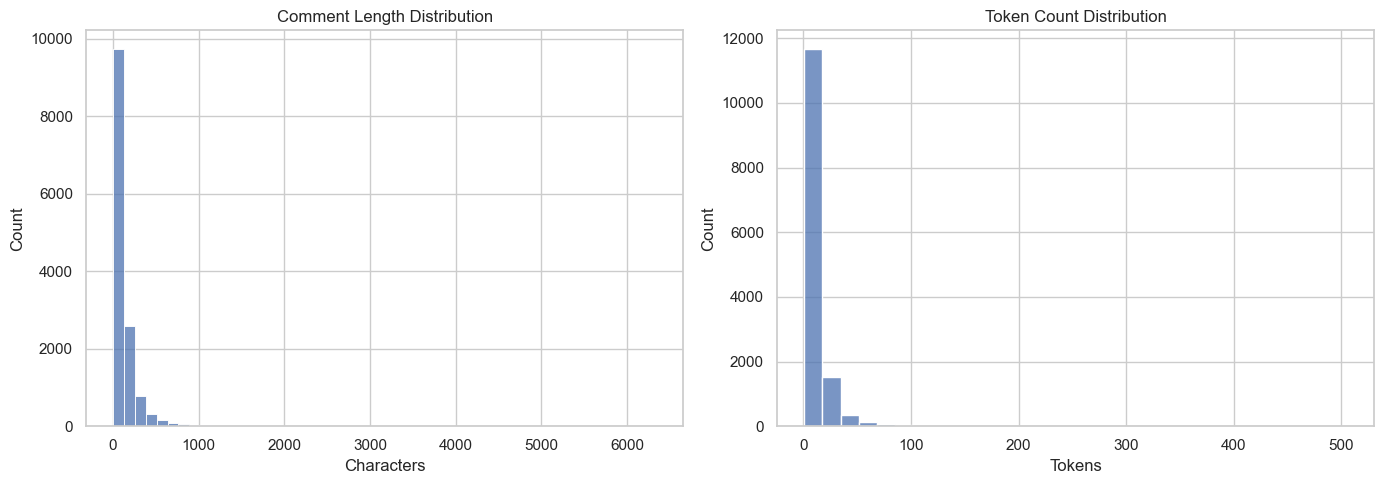

In [26]:
df["comment_length"] = df["text_clean_basic"].str.len()
df["token_count"] = df[TOKEN_COL].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["comment_length"], bins=50, ax=axes[0])
axes[0].set_title("Comment Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(df["token_count"], bins=30, ax=axes[1])
axes[1].set_title("Token Count Distribution")
axes[1].set_xlabel("Tokens")

plt.tight_layout()
plt.show()

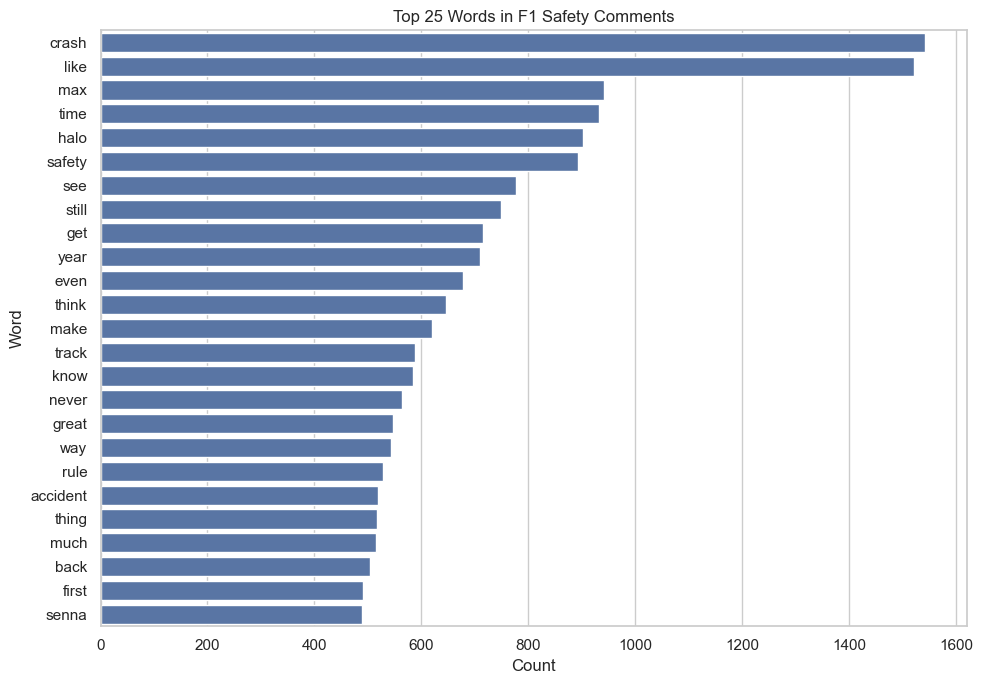

,word,count
0,crash,1543
1,like,1521
2,max,941
3,time,933
4,halo,903
5,safety,894
6,see,777
7,still,749
8,get,716
9,year,710


In [27]:
# Top words after preprocessing
all_tokens = [tok for toks in df[TOKEN_COL] for tok in toks]
top_words = pd.DataFrame(Counter(all_tokens).most_common(25), columns=["word", "count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_words, y="word", x="count")
plt.title("Top 25 Words in F1 Safety Comments")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

top_words.head(10)

## 11. TF-IDF and Bigrams

TF-IDF helps identify distinctive terms, while bigrams reveal important phrases such as “halo saved”, “safety car”, or “fia rules”.

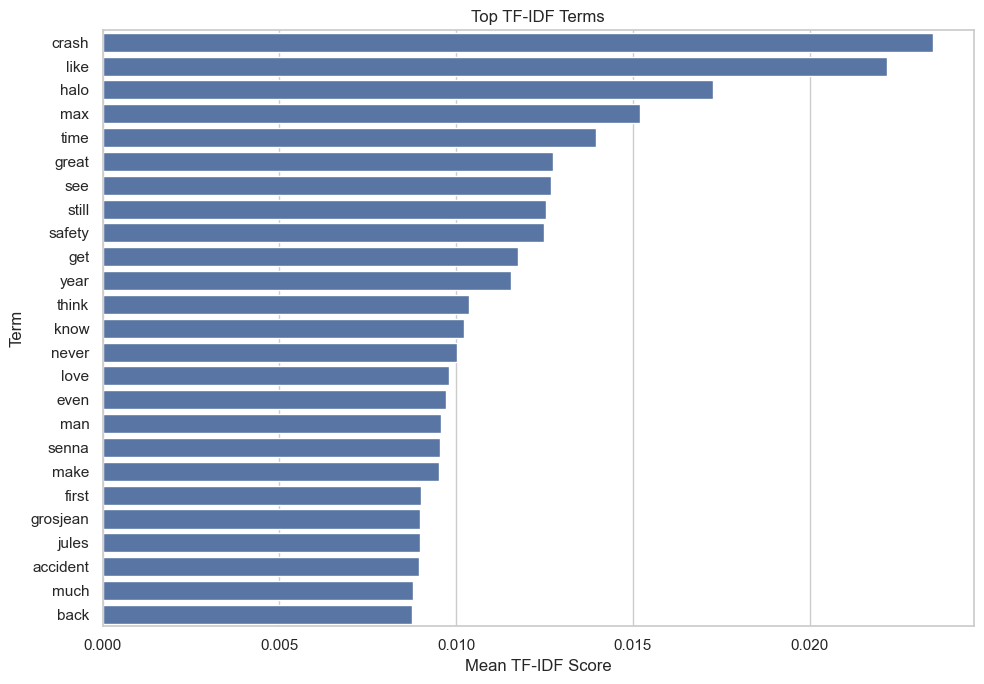

,term,score
178,crash,0.023475
514,like,0.022186
383,halo,0.017262
556,max,0.015206
893,time,0.013959
370,great,0.012746
772,see,0.012673
838,still,0.012532
753,safety,0.012487
352,get,0.011755


In [28]:
tfidf = TfidfVectorizer(max_features=1000, min_df=3, max_df=0.85)
X_tfidf = tfidf.fit_transform(df[TEXT_COL])

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_terms = tfidf.get_feature_names_out()

top_tfidf = pd.DataFrame({"term": tfidf_terms, "score": tfidf_scores})     .sort_values("score", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_tfidf, y="term", x="score")
plt.title("Top TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

top_tfidf.head(10)

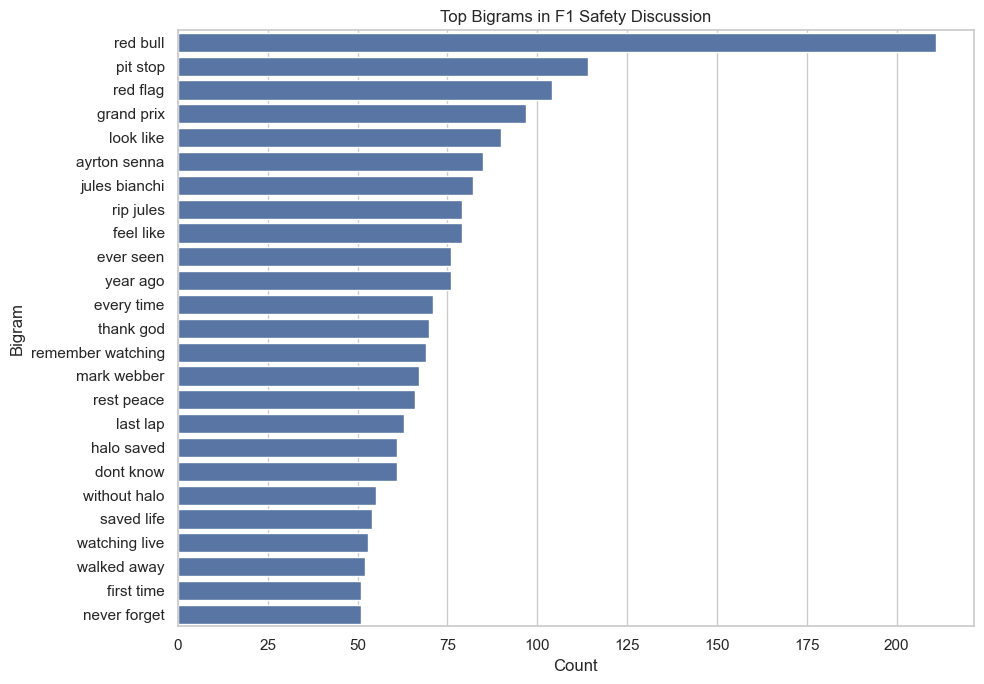

,bigram,count
341,red bull,211
330,pit stop,114
342,red flag,104
168,grand prix,97
249,look like,90
13,ayrton senna,85
217,jules bianchi,82
353,rip jules,79
116,feel like,79
101,ever seen,76


In [29]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=3, max_features=500)
X_bigrams = bigram_vectorizer.fit_transform(df[TEXT_COL])

bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()
bigram_terms = bigram_vectorizer.get_feature_names_out()

top_bigrams = pd.DataFrame({"bigram": bigram_terms, "count": bigram_counts})     .sort_values("count", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_bigrams, y="bigram", x="count")
plt.title("Top Bigrams in F1 Safety Discussion")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

top_bigrams.head(10)

## 12. Sentiment Analysis: VADER and TextBlob

VADER is suitable for social media text because it handles informal language, punctuation, and intensity. TextBlob is added as a second lexicon-based comparison method.

In [30]:
sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        label = "positive"
    elif score <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return score, label


def textblob_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
    return polarity, label

vader_results = df["text_clean_basic"].apply(vader_label)
blob_results = df["text_clean_basic"].apply(textblob_label)

df["vader_score"] = vader_results.apply(lambda x: x[0])
df["vader_label"] = vader_results.apply(lambda x: x[1])
df["blob_score"] = blob_results.apply(lambda x: x[0])
df["blob_label"] = blob_results.apply(lambda x: x[1])

df[["text_clean_basic", "vader_score", "vader_label", "blob_score", "blob_label"]].head()

,text_clean_basic,vader_score,vader_label,blob_score,blob_label
0,The fact Gasly did such a great job at avoiding crashing into a spinning Max Verstappen head on only to get rolled i...,-0.4404,negative,-0.015,neutral
1,Thank you Jolyon for explaining the Lawson / Gasly incident. So many blaming Lawson when he clearly was a passenger ...,0.1832,positive,0.300,positive
2,The opening 10 laps or so were crazy!,-0.4534,negative,-0.750,negative
3,Gasly so chill about being flipped over while his engineer doesnt even know hes crashed 😂,0.0000,neutral,0.000,neutral
4,That wasn't a chop from Max on Lando. It was a blatant block.,-0.4404,negative,-0.500,negative


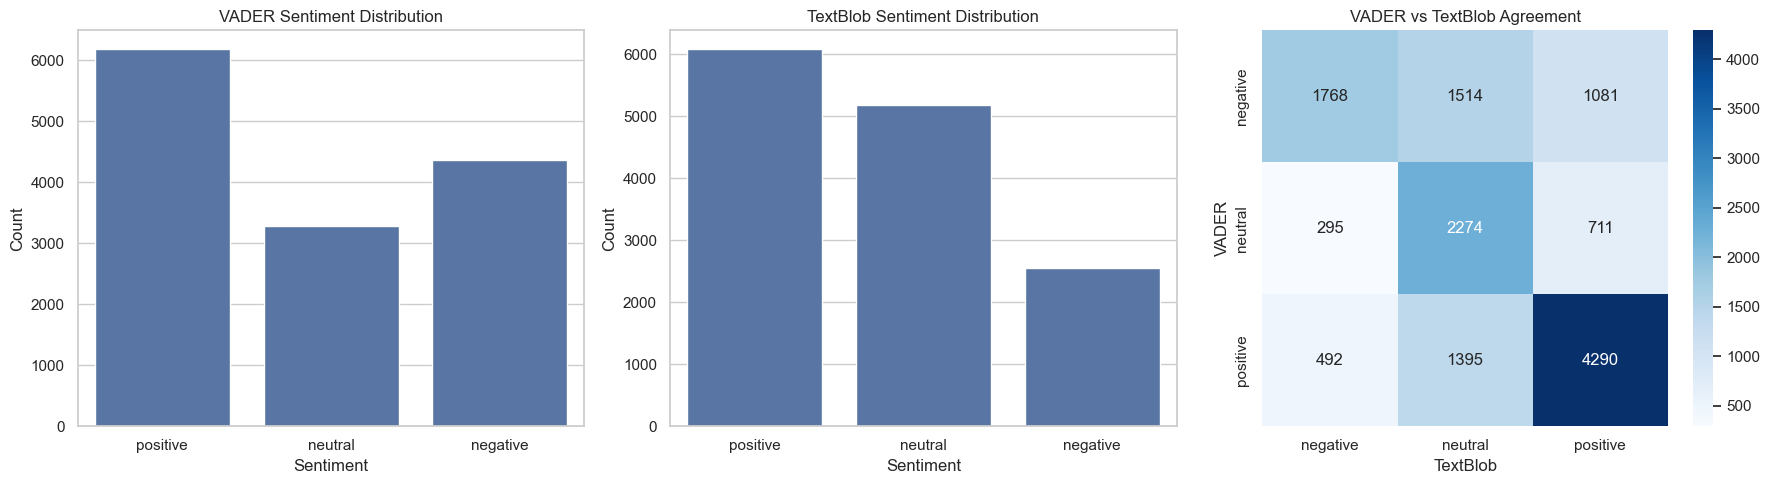

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="vader_label", order=["positive", "neutral", "negative"], ax=axes[0])
axes[0].set_title("VADER Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="blob_label", order=["positive", "neutral", "negative"], ax=axes[1])
axes[1].set_title("TextBlob Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

agreement = pd.crosstab(df["vader_label"], df["blob_label"])
sns.heatmap(agreement, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("VADER vs TextBlob Agreement")
axes[2].set_xlabel("TextBlob")
axes[2].set_ylabel("VADER")

plt.tight_layout()
plt.show()